In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

sns.set_style("whitegrid")

print("Libraries Loaded")

Libraries Loaded


In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
nav = nav.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

In [6]:
nav.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [7]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [8]:
nav[
    ["amfi_code",
     "date",
     "nav",
     "daily_return"]
].head(15)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


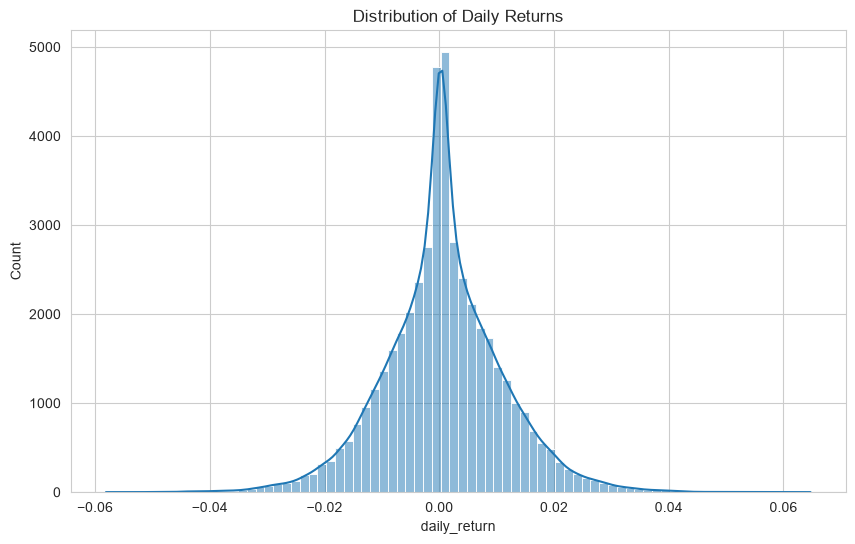

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"],
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [10]:
plt.savefig("../charts/daily_return_distribution.png")

<Figure size 640x480 with 0 Axes>

In [11]:
latest = nav["date"].max()

years = [1,3,5]

cagr = []

In [12]:
for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"]==code
    ].sort_values("date")

    row = {
        "amfi_code":code
    }

    for y in years:

        end = df.iloc[-1]

        start_date = latest - pd.DateOffset(years=y)

        start = df[
            df["date"]>=start_date
        ].iloc[0]

        value = (
            (end["nav"]/start["nav"])
            **(1/y)-1
        )

        row[f"CAGR_{y}Y"] = value

    cagr.append(row)

In [13]:
cagr = pd.DataFrame(cagr)

cagr = cagr.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [14]:
cagr.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

In [15]:
risk_free = 0.065

sharpe = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    mean_return = df["daily_return"].mean() * 252

    volatility = df["daily_return"].std() * np.sqrt(252)

    sharpe_ratio = (mean_return - risk_free) / volatility

    sharpe.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe_ratio
    })

In [16]:
sharpe = pd.DataFrame(sharpe)

sharpe = sharpe.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.head(10)

,amfi_code,Sharpe_Ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [17]:
sharpe.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

In [18]:
sortino = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    mean_return = df["daily_return"].mean() * 252

    downside = df[df["daily_return"] < 0]["daily_return"]

    downside_std = downside.std() * np.sqrt(252)

    sortino_ratio = (mean_return - risk_free) / downside_std

    sortino.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino_ratio
    })

In [19]:
sortino = pd.DataFrame(sortino)

sortino = sortino.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

sortino = sortino.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino.head(10)

,amfi_code,Sortino_Ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [20]:
sortino.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

TASK 5 ALPHA &BEETA USING OLS REGRESSION


In [21]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

nifty100.head()

KeyError: "['benchmark_return'] not in index"

In [ ]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value', 'benchmark_return']


In [ ]:
benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [ ]:
print(nifty100.shape)

(1150, 2)


In [ ]:
merged = nav.merge(
    nifty100,
    on="date",
    how="inner"
)

print(merged.shape)
merged.head()

(46000, 6)


,amfi_code,date,nav,scheme_name,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN,NaN
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865,0.004003
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210,0.006150


In [ ]:
print(merged["date"].min(), merged["date"].max())

2022-01-03 00:00:00 2026-05-29 00:00:00


In [ ]:
print(nav["date"].min())
print(nav["date"].max())

print(nifty100["date"].min())
print(nifty100["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00
2022-01-03 00:00:00
2026-05-29 00:00:00


# Task 6: Maximum Drawdown
Calculate the maximum drawdown for each mutual fund and identify the worst drawdown period.

In [ ]:
drawdowns = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] /
        group["running_max"] - 1
    )

    worst = group.loc[group["drawdown"].idxmin()]

    drawdowns.append({
        "amfi_code": code,
        "Maximum_Drawdown": worst["drawdown"],
        "Worst_Date": worst["date"]
    })

In [ ]:
drawdowns = pd.DataFrame(drawdowns)

drawdowns = drawdowns.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

drawdowns = drawdowns.sort_values(
    "Maximum_Drawdown"
)

drawdowns.head()

,amfi_code,Maximum_Drawdown,Worst_Date,scheme_name
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth


In [ ]:
drawdowns.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown saved.")

Maximum Drawdown saved.


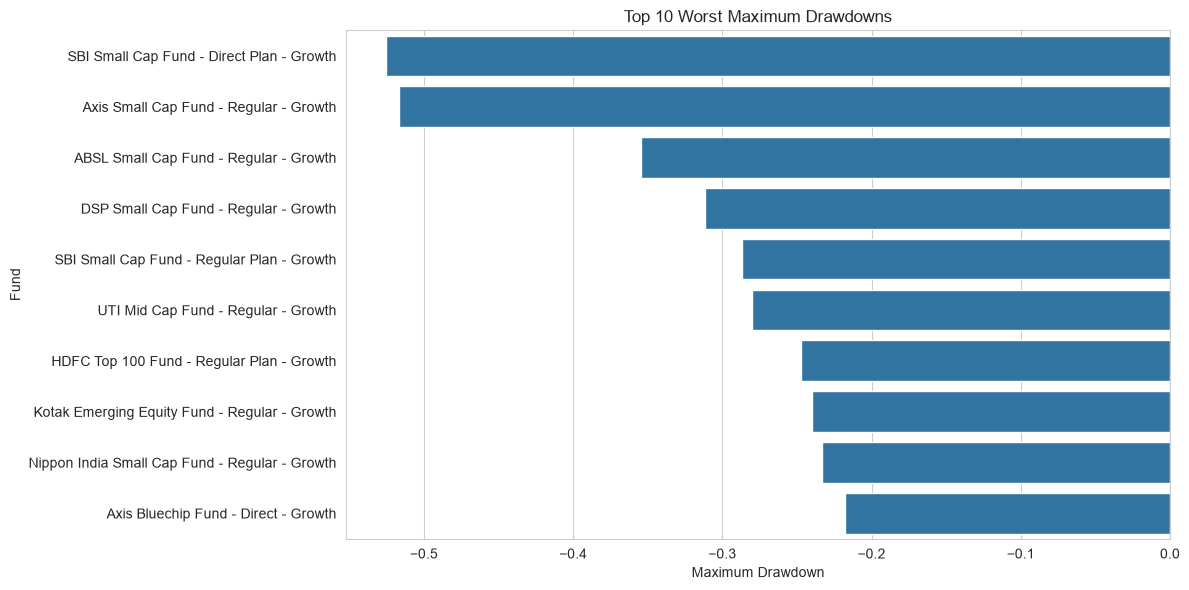

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=drawdowns.head(10),
    x="Maximum_Drawdown",
    y="scheme_name"
)

plt.title("Top 10 Worst Maximum Drawdowns")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig("../charts/maximum_drawdown.png")

plt.show()

# Task 7: Fund Scorecard (0–100)

Composite score based on:

- 30% CAGR 3Y
- 25% Sharpe Ratio
- 20% Alpha
- 15% Expense Ratio (inverse)
- 10% Maximum Drawdown (inverse)

In [ ]:
scorecard = cagr.copy()

scorecard = scorecard.merge(
    sharpe,
    on=["amfi_code", "scheme_name"]
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code","Alpha","Beta"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdowns[["amfi_code","Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[["amfi_code","expense_ratio_pct"]],
    on="amfi_code"
)

scorecard.head()

TypeError: Can only merge Series or DataFrame objects, a <class 'numpy.float64'> was passed

In [ ]:
print(type(cagr))
print(type(sharpe_ratio))
print(type(alpha_beta))
print(type(drawdowns))

<class 'pandas.DataFrame'>
<class 'numpy.float64'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [ ]:
print(sharpe_ratio)

0.9497958246616031


In [ ]:
print(type(sharpe_ratio))

<class 'numpy.float64'>


In [ ]:
sharpe_list = []

for code, group in nav.groupby("amfi_code"):
    mean_return = group["daily_return"].mean() * 252
    std_return = group["daily_return"].std()

    sharpe = (mean_return - 0.065) / (std_return * np.sqrt(252))

    sharpe_list.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

sharpe_ratio = pd.DataFrame(sharpe_list)

sharpe_ratio = sharpe_ratio.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_ratio.head()

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [ ]:
print(type(sharpe_ratio))
print(sharpe_ratio)

<class 'pandas.DataFrame'>
    amfi_code  Sharpe_Ratio                                        scheme_name
0      100016     -0.201517          HDFC Top 100 Fund - Regular Plan - Growth
1      100025     -0.567095       HDFC Short Term Debt Fund - Regular - Growth
2      100033      1.093699  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3      101206      1.027213      ABSL Frontline Equity Fund - Regular - Growth
4      101207      0.162661             ABSL Small Cap Fund - Regular - Growth
5      101208     -0.815567                ABSL Liquid Fund - Regular - Growth
6      102885      0.817099         UTI Nifty 50 Index Fund - Regular - Growth
7      102886     -0.205832                UTI Mid Cap Fund - Regular - Growth
8      102887      0.619518              UTI Flexi Cap Fund - Regular - Growth
9      118632      1.081659     Nippon India Large Cap Fund - Regular - Growth
10     118633      0.645207      Nippon India Large Cap Fund - Direct - Growth
11     118634      0.4484

In [ ]:
scorecard = scorecard.merge(
    sharpe_df,
    on=["amfi_code", "scheme_name"]
)

In [ ]:
print("cagr:", type(cagr))
print("sharpe:", type(sharpe))
print("alpha_beta:", type(alpha_beta))
print("drawdowns:", type(drawdowns))
print("performance:", type(performance))

cagr: <class 'pandas.DataFrame'>
sharpe: <class 'numpy.float64'>
alpha_beta: <class 'pandas.DataFrame'>
drawdowns: <class 'pandas.DataFrame'>
performance: <class 'pandas.DataFrame'>


In [ ]:
risk_free = 0.065

sharpe_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    mean_return = df["daily_return"].mean() * 252
    volatility = df["daily_return"].std() * np.sqrt(252)

    sharpe_value = (mean_return - risk_free) / volatility

    sharpe_list.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe_value
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


TASK 8 NOW


In [ ]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

top5_nav.head()

,amfi_code,date,nav,scheme_name,daily_return
5750,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,NaN
5751,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306
5752,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865
5753,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377
5754,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210


In [ ]:
benchmarks = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmarks.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


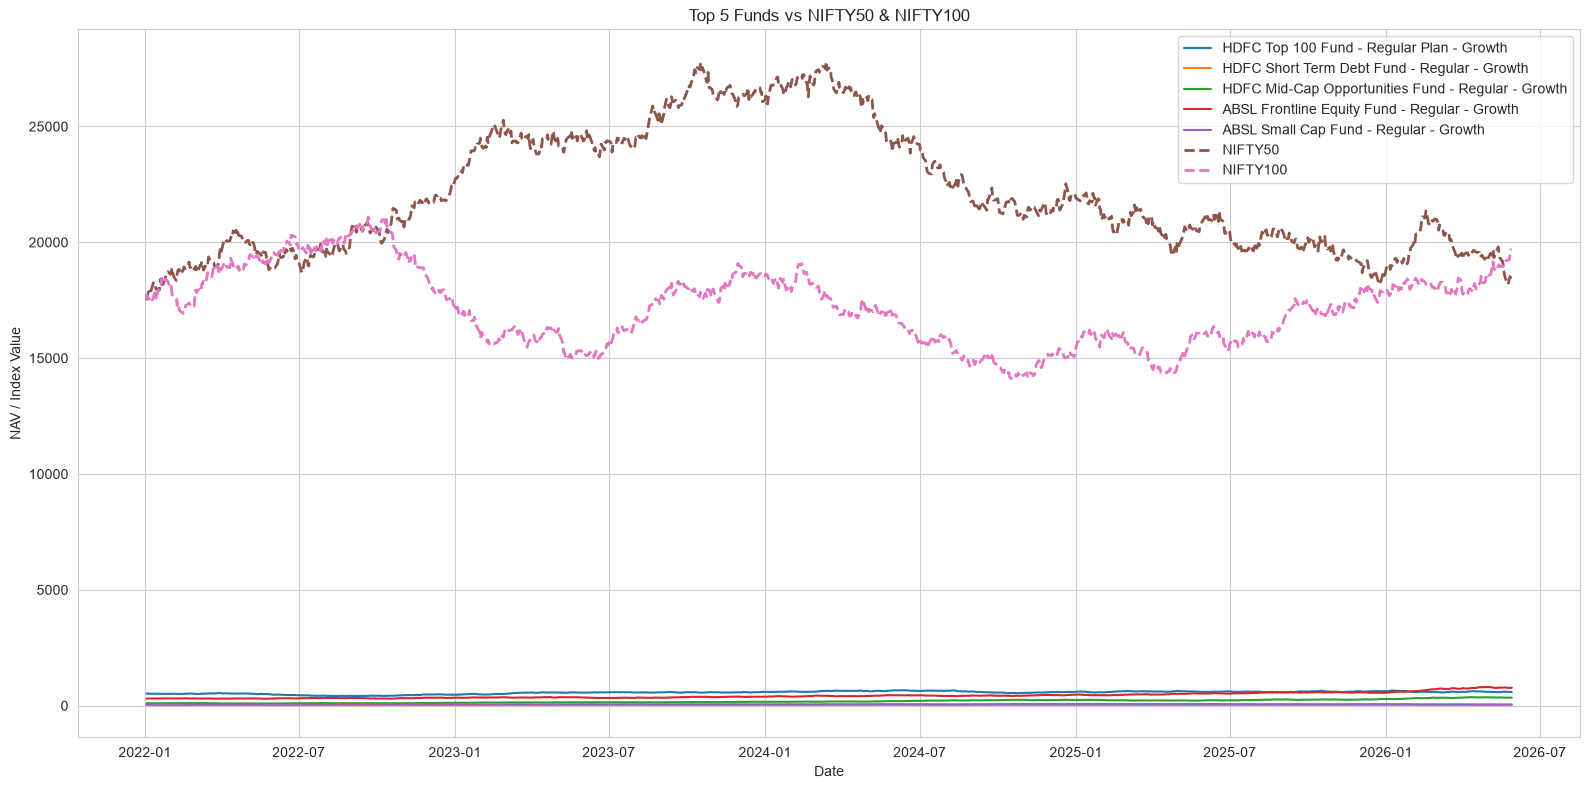

In [ ]:
plt.figure(figsize=(16,8))

# Plot Top 5 Funds
for code in top5:
    temp = top5_nav[top5_nav["amfi_code"] == code]
    plt.plot(
        temp["date"],
        temp["nav"],
        label=temp["scheme_name"].iloc[0]
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:
    temp = benchmarks[benchmarks["index_name"] == idx]
    plt.plot(
        temp["date"],
        temp["close_value"],
        linestyle="--",
        linewidth=2,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()
plt.tight_layout()

plt.savefig("../charts/benchmark_comparison.png")

plt.show()

In [ ]:
print(top5_nav.columns)

Index(['amfi_code', 'date', 'nav', 'scheme_name_x', 'daily_return',
       'scheme_name_y'],
      dtype='str')


In [ ]:
tracking_error = []

for code in top5:

    fund = nav[nav["amfi_code"] == code][
        ["date", "daily_return"]
    ]

    nifty = benchmark[
        benchmark["index_name"] == "NIFTY100"
    ][["date", "benchmark_return"]]

    merged = fund.merge(
        nifty,
        on="date"
    ).dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std() * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": code,
        "Tracking_Error": te
    })

In [ ]:
tracking_error = pd.DataFrame(tracking_error)

tracking_error = tracking_error.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

tracking_error = tracking_error.sort_values(
    "Tracking_Error"
)

tracking_error

,amfi_code,Tracking_Error,scheme_name
1,100025,0.134535,HDFC Short Term Debt Fund - Regular - Growth
3,101206,0.192706,ABSL Frontline Equity Fund - Regular - Growth
0,100016,0.199284,HDFC Top 100 Fund - Regular Plan - Growth
2,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,101207,0.292117,ABSL Small Cap Fund - Regular - Growth


In [ ]:
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error Report Saved Successfully")

Tracking Error Report Saved Successfully


makin file fund


In [22]:
print(type(cagr))
print(type(sharpe))
print(type(alpha_beta))
print(type(drawdowns))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


NameError: name 'alpha_beta' is not defined

In [23]:
import os

print(os.listdir("../data"))

['processed', 'raw']


In [24]:
from scipy.stats import linregress
import pandas as pd

In [28]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

nifty100.head()

KeyError: "['benchmark_return'] not in index"

In [29]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [30]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [31]:
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[us]
 1   index_name   8050 non-null   str           
 2   close_value  8050 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 188.8 KB


In [32]:
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [33]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [34]:
merged = daily_returns.merge(
    nifty100,
    on="date",
    how="inner"
)

NameError: name 'daily_returns' is not defined

In [36]:
if "nav_history" not in globals():
    print("nav_history not found, using nav as the source dataframe.")
    nav_history = nav[["amfi_code", "date", "nav"]].copy()

print(nav_history.columns.tolist())
nav_history.head()

nav_history["date"] = pd.to_datetime(nav_history["date"])
nav_history = nav_history.sort_values(["amfi_code", "date"])

daily_returns = nav_history.copy()
daily_returns["daily_return"] = (
    daily_returns.groupby("amfi_code")["nav"]
    .pct_change()
)
daily_returns = daily_returns.dropna()
daily_returns.head()

merged = daily_returns.merge(
    nifty100,
    on="date",
    how="inner"
)
merged.head()

nav_history not found, using nav as the source dataframe.
['amfi_code', 'date', 'nav']


,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,-0.013540
1,100016,2022-01-05,521.7239,0.012865,0.004003
2,100016,2022-01-06,515.7880,-0.011377,-0.002935
3,100016,2022-01-07,515.1639,-0.001210,0.006150
4,100016,2022-01-10,510.7136,-0.008639,-0.008351


In [37]:
from scipy.stats import linregress

alpha_beta = []

for code, group in merged.groupby("amfi_code"):

    group = group.dropna()

    if len(group) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": alpha * 252,
        "Beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [38]:
alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [39]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created successfully!")

alpha_beta.csv created successfully!


In [42]:
# recompute alpha/beta and scorecard cleanly

benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark = benchmark.sort_values(["index_name", "date"])
benchmark["benchmark_return"] = benchmark.groupby("index_name")["close_value"].pct_change()

nifty100 = benchmark.loc[
    benchmark["index_name"] == "NIFTY100",
    ["date", "benchmark_return"]
].copy()

if "daily_returns" not in globals():
    nav_history = nav[["amfi_code", "date", "nav"]].copy()
    nav_history["date"] = pd.to_datetime(nav_history["date"])
    nav_history = nav_history.sort_values(["amfi_code", "date"])

    daily_returns = nav_history.copy()
    daily_returns["daily_return"] = (
        daily_returns.groupby("amfi_code")["nav"].pct_change()
    )
    daily_returns = daily_returns.dropna()

merged = daily_returns.merge(
    nifty100,
    on="date",
    how="inner"
).dropna()

alpha_beta = []
for code, group in merged.groupby("amfi_code"):
    if len(group) < 30:
        continue

    beta, alpha, _, _, _ = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": alpha * 252,
        "Beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta)
alpha_beta = alpha_beta.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_free = 0.065
sharpe_df = []
for code, group in daily_returns.groupby("amfi_code"):
    mean_return = group["daily_return"].mean() * 252
    volatility = group["daily_return"].std() * np.sqrt(252)

    sharpe_df.append({
        "amfi_code": code,
        "Sharpe_Ratio": (
            (mean_return - risk_free) / volatility
            if volatility != 0 else np.nan
        )
    })

sharpe_df = pd.DataFrame(sharpe_df)
sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdowns = []
for code, group in nav.sort_values(["amfi_code", "date"]).groupby("amfi_code"):
    group = group.copy()
    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = group["nav"] / group["running_max"] - 1

    worst = group.loc[group["drawdown"].idxmin()]
    drawdowns.append({
        "amfi_code": code,
        "Maximum_Drawdown": worst["drawdown"],
        "Worst_Date": worst["date"]
    })

drawdowns = pd.DataFrame(drawdowns)
drawdowns = drawdowns.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

scorecard = cagr.copy()
scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)
scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha", "Beta"]],
    on="amfi_code",
    how="left"
)
scorecard = scorecard.merge(
    drawdowns[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code",
    how="left"
)
scorecard = scorecard.merge(
    fund_master[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,0.162661,0.108971,-0.065289,-0.354469,1.53


In [43]:
print(scorecard.shape)
scorecard.head()

(40, 10)


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,0.162661,0.108971,-0.065289,-0.354469,1.53


In [44]:
scorecard["Return_Score"] = scorecard["CAGR_3Y"].rank(pct=True) * 100
scorecard["Sharpe_Score"] = scorecard["Sharpe_Ratio"].rank(pct=True) * 100
scorecard["Alpha_Score"] = scorecard["Alpha"].rank(pct=True) * 100
scorecard["Expense_Score"] = (
    100 - scorecard["expense_ratio_pct"].rank(pct=True) * 100
)
scorecard["Drawdown_Score"] = (
    100 - scorecard["Maximum_Drawdown"].rank(pct=True) * 100
)

scorecard["Fund_Score"] = (
    0.35 * scorecard["Return_Score"] +
    0.25 * scorecard["Sharpe_Score"] +
    0.20 * scorecard["Alpha_Score"] +
    0.10 * scorecard["Expense_Score"] +
    0.10 * scorecard["Drawdown_Score"]
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,Sharpe_Ratio,Alpha,Beta,Maximum_Drawdown,expense_ratio_pct,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score,Fund_Score
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth,1.180101,0.292636,0.000549,-0.181885,1.36,90.0,90.0,95.0,62.50,60.0,85.250
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth,0.998231,0.260767,-0.066265,-0.209609,1.38,100.0,75.0,80.0,57.50,67.5,82.250
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,0.269838,0.023684,-0.112657,1.46,97.5,100.0,85.0,42.50,17.5,82.125
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,0.005104,-0.162172,1.38,92.5,85.0,87.5,57.50,47.5,81.625
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth,1.306744,0.273305,-0.022830,-0.129740,1.45,85.0,97.5,90.0,45.00,30.0,79.625
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,0.282704,0.018134,-0.163967,1.60,82.5,95.0,92.5,8.75,50.0,77.000
39,149324,0.651387,0.270004,0.279174,DSP Small Cap Fund - Regular - Growth,0.949796,0.300579,0.011455,-0.311719,1.52,77.5,70.0,97.5,33.75,90.0,76.500
24,120504,0.130643,0.324874,0.202340,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,0.211948,0.016232,-0.125883,0.80,95.0,77.5,70.0,70.00,27.5,76.375
21,119598,0.827761,0.266699,0.280332,SBI Small Cap Fund - Regular Plan - Growth,0.945308,0.303370,-0.023196,-0.287060,1.43,72.5,67.5,100.0,47.50,87.5,75.750
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth,1.208267,0.232010,-0.031751,-0.150124,1.54,87.5,92.5,77.5,23.75,40.0,75.625


In [45]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("✅ fund_scorecard.csv saved")

✅ fund_scorecard.csv saved
